In [1]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\Landl\Downloads\Data-Science-Projects\sec-financial-nlp")

df_sentiment = pd.read_csv("data/processed/sentiment_results.csv")
print(f"Sentiment rows loaded: {len(df_sentiment)}")

KeyboardInterrupt: 

In [ ]:
def extract_year(key):
    """
    key format: TICKER_8-K_CIKNUMBER-YY-SEQUENCE
    Extracts the 2-digit year from the accession number and converts to 4-digit.
    """
    match = re.search(r'-(\d{2})-\d+$', key)
    yy = int(match.group(1))
    return 2000 + yy

df_sentiment['year'] = df_sentiment['key'].apply(extract_year)

In [ ]:
def get_8k_item_info(filepath):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        header = f.read(3000)
    return re.findall(r'ITEM INFORMATION:\s*(.+)', header)

item_info_map = {}
for ticker in ["AAPL", "MSFT", "GOOGL", "JPM", "TSLA"]:
    files = glob.glob(f"data/raw/sec-edgar-filings/{ticker}/8-K/*/full-submission.txt")
    for filepath in files:
        accession = os.path.basename(os.path.dirname(filepath))
        key = f"{ticker}_8-K_{accession}"
        item_info_map[key] = get_8k_item_info(filepath)

earnings_keys = set(
    k for k, items in item_info_map.items()
    if any("Results of Operations" in i for i in items)
)

df_sentiment['is_earnings'] = df_sentiment['key'].isin(earnings_keys)
df_earnings = df_sentiment[df_sentiment['is_earnings']].copy()
print(f"Earnings-related 8-Ks: {len(df_earnings)}")

Earnings-related 8-Ks: 43


In [ ]:
def signed_score(row):
    if row['label'] == 'positive':
        return row['score']
    elif row['label'] == 'negative':
        return -row['score']
    return 0.0

df_earnings['signed_sentiment'] = df_earnings.apply(signed_score, axis=1)

In [ ]:
def extract_seq(key):
    match = re.search(r'-\d{2}-(\d+)$', key)
    return int(match.group(1))

df_earnings['seq'] = df_earnings['key'].apply(extract_seq)
df_earnings = df_earnings.sort_values(['ticker', 'year', 'seq']).reset_index(drop=True)
df_earnings['period_label'] = df_earnings['year'].astype(str) + "-Q" + (df_earnings.groupby(['ticker', 'year']).cumcount() + 1).astype(str)

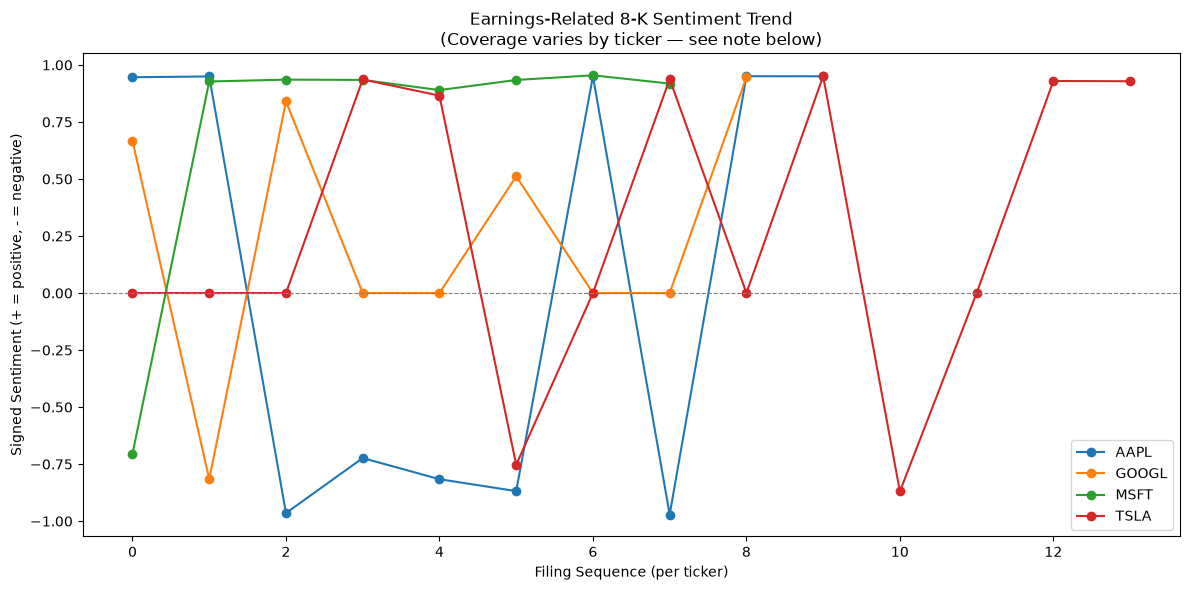

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in ["AAPL", "GOOGL", "MSFT", "TSLA"]:
    sub = df_earnings[df_earnings['ticker'] == ticker].reset_index(drop=True)
    x_positions = range(len(sub))  # 0, 1, 2, 3... just for this ticker
    ax.plot(x_positions, sub['signed_sentiment'], marker='o', label=ticker)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel("Filing Sequence (per ticker)")
ax.set_ylabel("Signed Sentiment (+ = positive, - = negative)")
ax.set_title("Earnings-Related 8-K Sentiment Trend\n(Coverage varies by ticker — see note below)")
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/sentiment_trend.png")
plt.show()

                            key  year     label   score  signed_sentiment
0  JPM_8-K_0000019617-24-000446  2024  positive  0.9416            0.9416
1  JPM_8-K_0000019617-24-000555  2024  positive  0.9299            0.9299


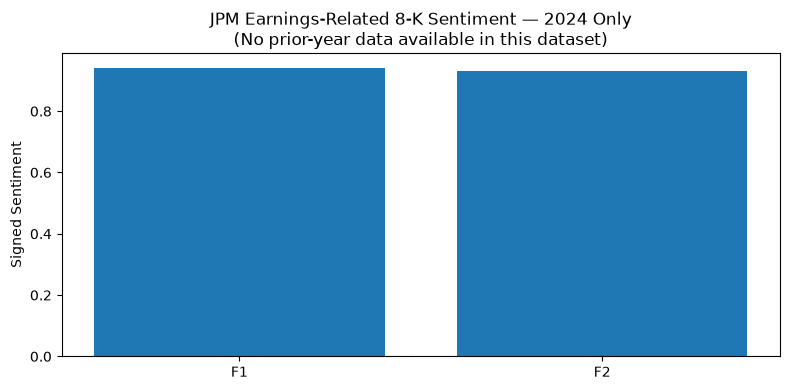

In [ ]:
jpm_2024 = df_earnings[df_earnings['ticker'] == 'JPM'].reset_index(drop=True)
print(jpm_2024[['key', 'year', 'label', 'score', 'signed_sentiment']])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(jpm_2024)), jpm_2024['signed_sentiment'])
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xticks(range(len(jpm_2024)))
ax.set_xticklabels([f"F{i+1}" for i in range(len(jpm_2024))])
ax.set_title("JPM Earnings-Related 8-K Sentiment — 2024 Only\n(No prior-year data available in this dataset)")
ax.set_ylabel("Signed Sentiment")
plt.tight_layout()
plt.savefig("data/processed/jpm_sentiment_2024.png")
plt.show()

Anomaly Detection

In [6]:
import os
os.chdir(r"C:\Users\Landl\Downloads\Data-Science-Projects\sec-financial-nlp")

In [7]:
import pickle

with open("data/processed/all_texts.pkl", "rb") as f:
    all_texts_fixed = pickle.load(f)

print(f"Filings loaded: {len(all_texts_fixed)}")  # should be 125

Filings loaded: 125


In [8]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model.eval()
print("Model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded


In [9]:
import re

def get_content_window(text, window_size=3000, min_gap=3000):
    text_lower = text.lower()
    words = text.split()
    item_1a_positions = [m.start() for m in re.finditer(r'item\s+1a', text_lower)]
    item_1b_positions = [m.start() for m in re.finditer(r'item\s+1b', text_lower)]
    best_pos = 0
    for pos_a in item_1a_positions:
        later_1b = [p for p in item_1b_positions if p > pos_a]
        if not later_1b:
            continue
        gap = min(later_1b) - pos_a
        if gap >= min_gap:
            best_pos = pos_a
            break
    start_word_idx = len(text[:best_pos].split())
    return " ".join(words[start_word_idx : start_word_idx + window_size])

In [10]:
def embed_texts(texts, tokenizer, model, batch_size=8):
    all_embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt")
            output = model(**encoded)
            token_embeddings = output.last_hidden_state
            mask = encoded["attention_mask"].unsqueeze(-1).expand(token_embeddings.size()).float()
            summed = torch.sum(token_embeddings * mask, dim=1)
            counts = torch.clamp(mask.sum(dim=1), min=1e-9)
            batch_embeddings = summed / counts
            all_embeddings.append(batch_embeddings)
    return torch.cat(all_embeddings, dim=0).numpy()

In [11]:
def chunk_filing(text, chunk_size=350, overlap=70):
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunks.append(" ".join(words[start:end]))
        start += chunk_size - overlap
    return chunks

def get_document_embedding(text, tokenizer, model):
    chunks = chunk_filing(text)
    chunk_embeddings = embed_texts(chunks, tokenizer, model)
    return chunk_embeddings.mean(axis=0)

In [13]:
import pandas as pd
import numpy as np

tenk_keys = [k for k in all_texts_fixed if "10-K" in k]
print(f"10-K filings found: {len(tenk_keys)}")

doc_embeddings = []
for key in tenk_keys:
    emb = get_document_embedding(all_texts_fixed[key], tokenizer, model)
    doc_embeddings.append(emb)
    print(f"{key}: done")

embeddings = np.array(doc_embeddings)
print(f"Embeddings shape: {embeddings.shape}")

10-K filings found: 25


AAPL_10-K_0000320193-20-000096: done
AAPL_10-K_0000320193-21-000105: done
AAPL_10-K_0000320193-22-000108: done
AAPL_10-K_0000320193-23-000106: done
AAPL_10-K_0000320193-24-000123: done
MSFT_10-K_0000950170-23-035122: done
MSFT_10-K_0000950170-24-087843: done
MSFT_10-K_0001564590-20-034944: done
MSFT_10-K_0001564590-21-039151: done
MSFT_10-K_0001564590-22-026876: done
GOOGL_10-K_0001652044-20-000008: done
GOOGL_10-K_0001652044-21-000010: done
GOOGL_10-K_0001652044-22-000019: done
GOOGL_10-K_0001652044-23-000016: done
GOOGL_10-K_0001652044-24-000022: done
JPM_10-K_0000019617-20-000257: done
JPM_10-K_0000019617-21-000236: done
JPM_10-K_0000019617-22-000272: done
JPM_10-K_0000019617-23-000231: done
JPM_10-K_0000019617-24-000225: done
TSLA_10-K_0000950170-22-000796: done
TSLA_10-K_0000950170-23-001409: done
TSLA_10-K_0001564590-20-004475: done
TSLA_10-K_0001564590-21-004599: done
TSLA_10-K_0001628280-24-002390: done
Embeddings shape: (25, 384)


In [14]:
import numpy as np
import pandas as pd

tickers = [k.split("_")[0] for k in tenk_keys]

def cosine_distance(a, b):
    return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

results = []

for ticker in ["AAPL", "MSFT", "GOOGL", "JPM", "TSLA"]:
    ticker_indices = [i for i, t in enumerate(tickers) if t == ticker]
    ticker_keys = [tenk_keys[i] for i in ticker_indices]
    ticker_embeddings = embeddings[ticker_indices]

    n = len(ticker_embeddings)
    for i in range(n):
        other_embeddings = np.delete(ticker_embeddings, i, axis=0)
        centroid = other_embeddings.mean(axis=0)
        dist = cosine_distance(ticker_embeddings[i], centroid)
        results.append({"ticker": ticker, "key": ticker_keys[i], "distance_from_centroid": dist})

df_anomaly = pd.DataFrame(results)
print(df_anomaly.sort_values(["ticker", "distance_from_centroid"]))

   ticker                              key  distance_from_centroid
2    AAPL   AAPL_10-K_0000320193-22-000108                0.005150
3    AAPL   AAPL_10-K_0000320193-23-000106                0.006867
4    AAPL   AAPL_10-K_0000320193-24-000123                0.007686
1    AAPL   AAPL_10-K_0000320193-21-000105                0.008419
0    AAPL   AAPL_10-K_0000320193-20-000096                0.011984
12  GOOGL  GOOGL_10-K_0001652044-22-000019                0.004126
13  GOOGL  GOOGL_10-K_0001652044-23-000016                0.005506
11  GOOGL  GOOGL_10-K_0001652044-21-000010                0.009167
10  GOOGL  GOOGL_10-K_0001652044-20-000008                0.009899
14  GOOGL  GOOGL_10-K_0001652044-24-000022                0.011314
17    JPM    JPM_10-K_0000019617-22-000272                0.001317
18    JPM    JPM_10-K_0000019617-23-000231                0.002429
16    JPM    JPM_10-K_0000019617-21-000236                0.004411
19    JPM    JPM_10-K_0000019617-24-000225                0.00

In [15]:
# test
for ticker in ["AAPL", "MSFT", "GOOGL", "JPM", "TSLA"]:
    ticker_keys_check = [k for k in tenk_keys if k.startswith(ticker)]
    lengths = [len(all_texts_fixed[k].split()) for k in ticker_keys_check]
    print(f"{ticker}: avg word count = {int(np.mean(lengths))}, range = {min(lengths)}-{max(lengths)}")

AAPL: avg word count = 22972, range = 22068-23843
MSFT: avg word count = 36445, range = 35402-37879
GOOGL: avg word count = 33564, range = 31938-35719
JPM: avg word count = 105104, range = 99862-113955
TSLA: avg word count = 43191, range = 37722-51219


In [16]:
df_anomaly_sorted = df_anomaly.sort_values(["ticker", "distance_from_centroid"], ascending=[True, False])
top_anomaly_per_ticker = df_anomaly_sorted.groupby("ticker").first().reset_index()

print("Most anomalous filing per ticker (within-ticker comparison only — NOT comparable across tickers due to document-length differences, see note):")
print(top_anomaly_per_ticker[["ticker", "key", "distance_from_centroid"]])

Most anomalous filing per ticker (within-ticker comparison only — NOT comparable across tickers due to document-length differences, see note):
  ticker                              key  distance_from_centroid
0   AAPL   AAPL_10-K_0000320193-20-000096                0.011984
1  GOOGL  GOOGL_10-K_0001652044-24-000022                0.011314
2    JPM    JPM_10-K_0000019617-20-000257                0.004419
3   MSFT   MSFT_10-K_0000950170-24-087843                0.012326
4   TSLA   TSLA_10-K_0001564590-20-004475                0.011221


In [17]:
df_anomaly.to_csv("data/processed/anomaly_detection_results.csv", index=False)
print("Saved anomaly_detection_results.csv")

Saved anomaly_detection_results.csv


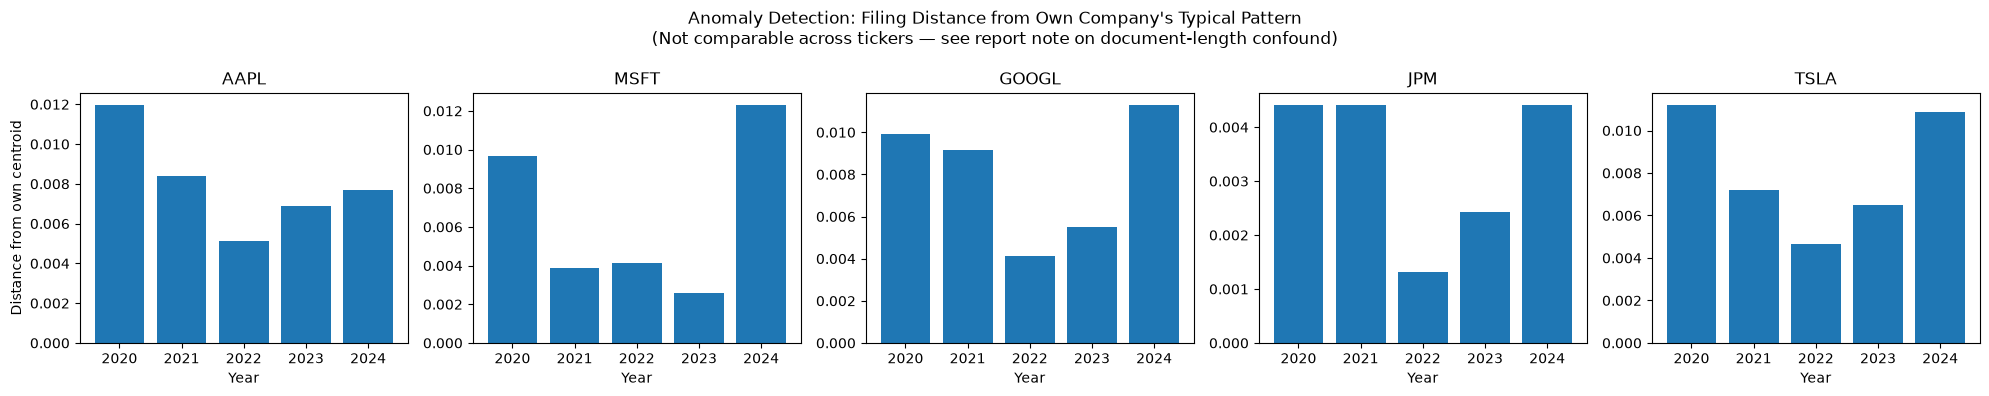

In [19]:
import matplotlib.pyplot as plt
import re

def extract_year(key):
    match = re.search(r'-(\d{2})-\d+$', key)
    yy = int(match.group(1))
    return 2000 + yy

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)

for ax, ticker in zip(axes, ["AAPL", "MSFT", "GOOGL", "JPM", "TSLA"]):
    sub = df_anomaly[df_anomaly["ticker"] == ticker].copy()
    sub["year"] = sub["key"].apply(lambda k: extract_year(k))
    sub = sub.sort_values("year")
    ax.bar(sub["year"].astype(str), sub["distance_from_centroid"])
    ax.set_title(ticker)
    ax.set_xlabel("Year")
    if ticker == "AAPL":
        ax.set_ylabel("Distance from own centroid")

fig.suptitle("Anomaly Detection: Filing Distance from Own Company's Typical Pattern\n(Not comparable across tickers — see report note on document-length confound)")
plt.tight_layout()
plt.savefig("data/processed/anomaly_detection_chart.png")
plt.show()